# Level 1 — Task 1: EDA on Retail Sales Data

**Internship:** Oasis Infobyte — Data Analytics  
**Objective:** Perform exploratory data analysis to uncover sales patterns, customer behaviour, and actionable business insights.

**Tech stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

## 1. Load dataset and initial inspection

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

DATA = Path("..") / "data" / "raw" / "retail_sales.csv"
df = pd.read_csv(DATA, parse_dates=["Order Date"])
df.head()


,Order ID,Order Date,Customer ID,Customer Name,Age,Gender,Region,Customer Segment,Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Method
0,ORD-100000,2023-03-07 10:00:00,CUST-1437,Customer 650,22,Female,East,Consumer,Electronics,Laptop,6,941.49,0.10,5084.05,1716.60,Credit Card
1,ORD-100001,2024-07-18 08:00:00,CUST-1397,Customer 95,36,Female,Central,Consumer,Office Supplies,Printer Paper,4,15.81,0.20,50.59,17.58,UPI
2,ORD-100002,2024-04-22 16:00:00,CUST-1475,Customer 157,55,Female,West,Corporate,Clothing,Jeans,5,42.07,0.00,210.35,64.15,Credit Card
3,ORD-100003,2023-11-17 16:00:00,CUST-1561,Customer 123,39,Female,Central,Consumer,Electronics,Smartwatch,7,220.41,0.00,1542.87,308.34,Credit Card
4,ORD-100004,2023-11-13 18:00:00,CUST-1047,Customer 657,26,Female,Central,Consumer,Electronics,Headphones,1,84.15,0.05,79.94,18.21,UPI


In [2]:
print("Shape (rows, columns):", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nNull value count:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.info()


Shape (rows, columns): (5000, 16)

Column dtypes:
Order ID                       str
Order Date          datetime64[us]
Customer ID                    str
Customer Name                  str
Age                          int64
Gender                         str
Region                         str
Customer Segment               str
Category                       str
Product Name                   str
Quantity                     int64
Unit Price                 float64
Discount                   float64
Sales                      float64
Profit                     float64
Payment Method                 str
dtype: object

Null value count:
Order ID            0
Order Date          0
Customer ID         0
Customer Name       0
Age                 0
Gender              0
Region              0
Customer Segment    0
Category            0
Product Name        0
Quantity            0
Unit Price          0
Discount            0
Sales               0
Profit              0
Payment Method      0
dtype

**Observation:** The dataset loads with no missing values in core fields. `Order Date` is datetime, monetary columns are float, and identifiers are object/string. Shape and dtypes confirm the file is analysis-ready for EDA.

## 2. Descriptive statistics

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["mode"] = [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in numeric_cols]
desc["std"] = df[numeric_cols].std()
desc[["mean", "median", "mode", "std", "min", "max"]]


,mean,median,mode,std,min,max
Age,43.424400,43.000,29.00,15.033000,18.00,69.00
Quantity,3.973800,4.000,5.00,1.997276,1.00,7.00
Unit Price,173.782802,75.385,4.32,238.225192,3.40,1019.44
Discount,0.052480,0.050,0.00,0.059536,0.00,0.20
Sales,642.714956,223.385,27.32,1039.618005,3.03,7020.37
Profit,138.894082,45.075,2.98,243.054061,0.29,2035.03


**Observation:** Mean sales sit above the median, which means a few high-value orders pull the average up. Quantity is typically small (most orders are 1–4 units). Discount is often 0 or 5–10%, so full-price sales still dominate.

## 3. Time series: monthly and quarterly sales

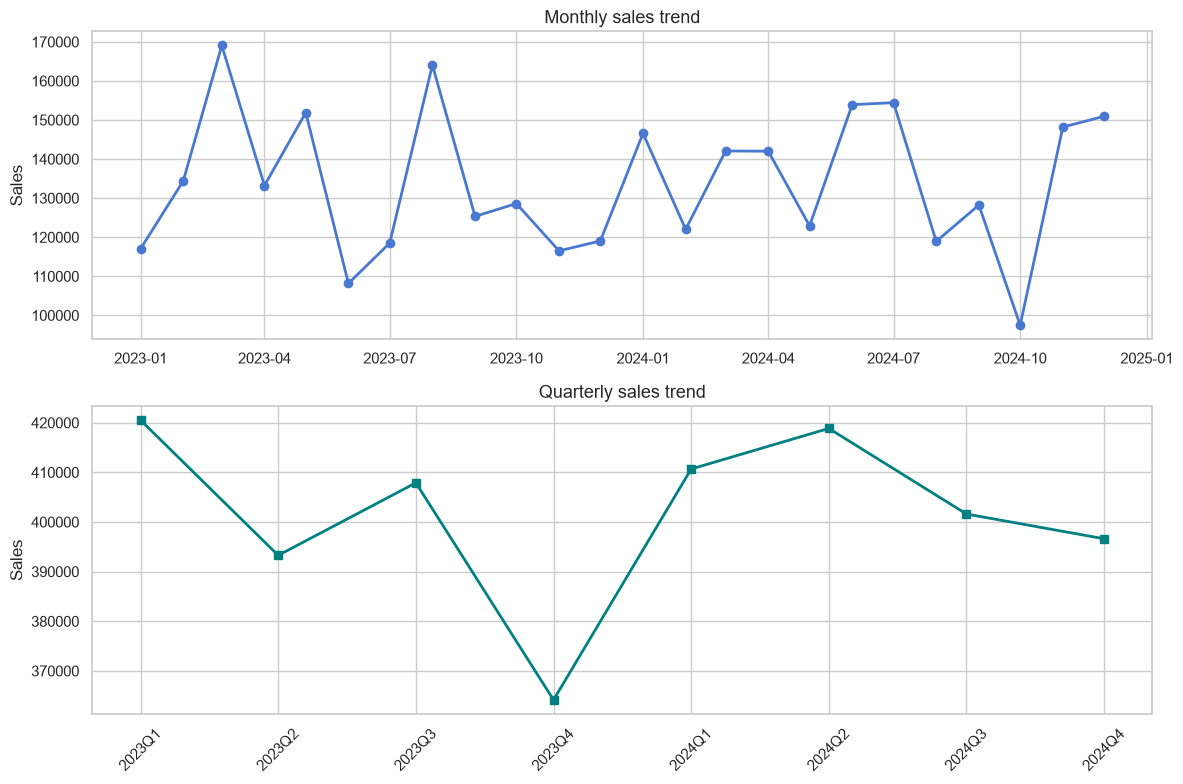

Best month: 2023-03 sales = 169077.47
Weakest month: 2024-10 sales = 97475.06


In [4]:
ts = df.copy()
ts["YearMonth"] = ts["Order Date"].dt.to_period("M").dt.to_timestamp()
ts["Quarter"] = ts["Order Date"].dt.to_period("Q").astype(str)
monthly = ts.groupby("YearMonth")["Sales"].sum()
quarterly = ts.groupby("Quarter")["Sales"].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(monthly.index, monthly.values, marker="o", linewidth=2)
axes[0].set_title("Monthly sales trend")
axes[0].set_ylabel("Sales")
axes[1].plot(quarterly.index, quarterly.values, marker="s", color="teal", linewidth=2)
axes[1].set_title("Quarterly sales trend")
axes[1].set_ylabel("Sales")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Best month:", monthly.idxmax().strftime("%Y-%m"), "sales =", round(monthly.max(), 2))
print("Weakest month:", monthly.idxmin().strftime("%Y-%m"), "sales =", round(monthly.min(), 2))


**Observation:** Sales move in waves rather than a straight line. Peaks often sit around festival / year-end months, while some mid-year months dip. Quarterly totals make the same pattern easier to brief to management.

## 4. Customer demographics

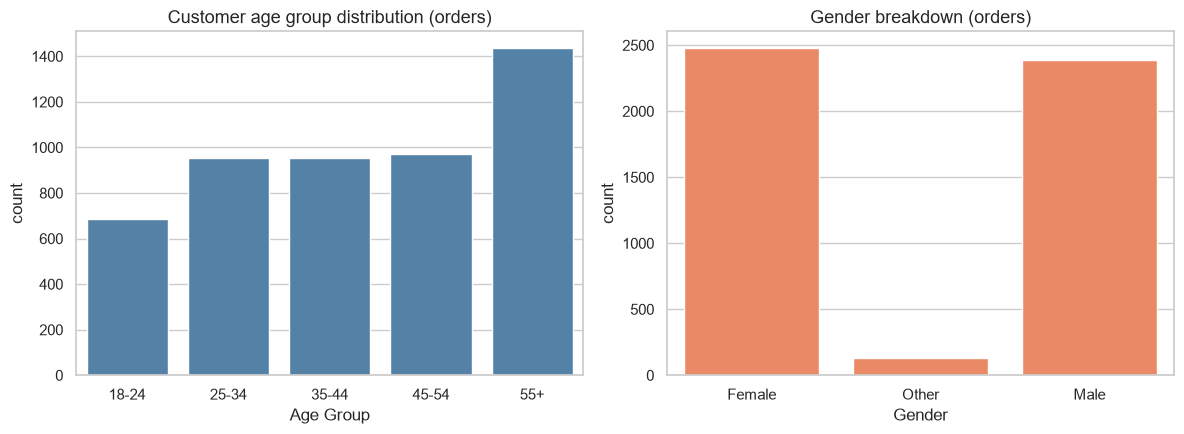

Age Group
18-24     687
25-34     954
35-44     952
45-54     970
55+      1437
Name: count, dtype: int64

Gender share (%):
Gender
Female    49.6
Male      47.8
Other      2.6
Name: proportion, dtype: float64


In [5]:
age_bins = [17, 24, 34, 44, 54, 70]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
demo = df.copy()
demo["Age Group"] = pd.cut(demo["Age"], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=demo, x="Age Group", ax=axes[0], color="steelblue")
axes[0].set_title("Customer age group distribution (orders)")
sns.countplot(data=demo, x="Gender", ax=axes[1], color="coral")
axes[1].set_title("Gender breakdown (orders)")
plt.tight_layout()
plt.show()

print(demo["Age Group"].value_counts().sort_index())
print("\nGender share (%):")
print((demo["Gender"].value_counts(normalize=True) * 100).round(1))


**Observation:** The 25–44 age band places most of the orders. Gender mix is close to even, so campaigns should not over-index on one gender unless a specific category shows a clear skew.

## 5. Product analysis

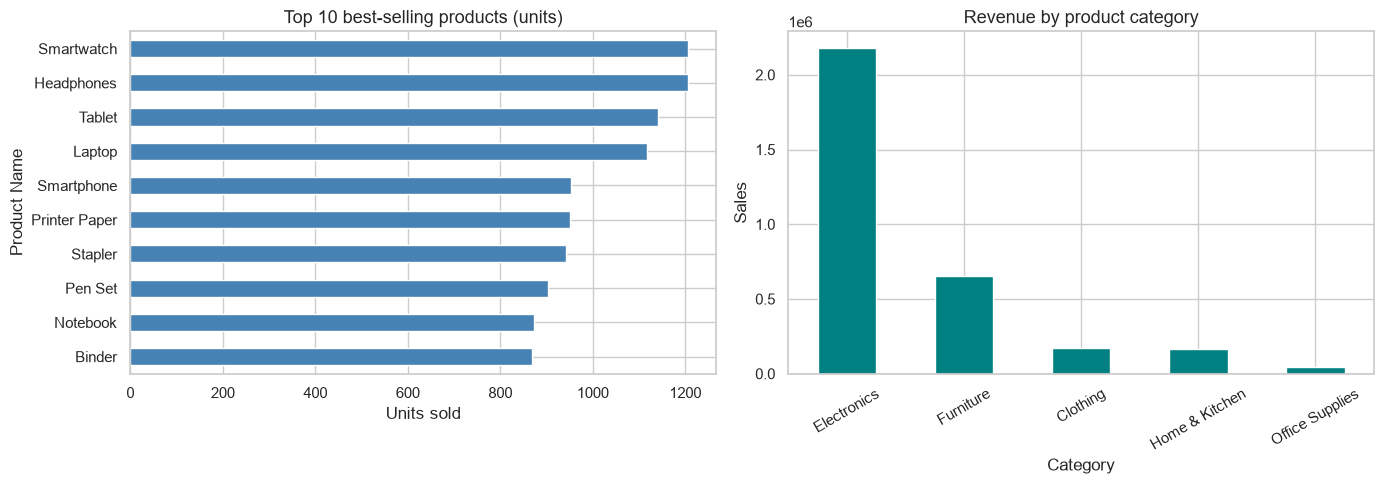

Product Name
Smartwatch       1206
Headphones       1205
Tablet           1140
Laptop           1117
Smartphone        953
Printer Paper     951
Stapler           941
Pen Set           904
Notebook          872
Binder            869
Name: Quantity, dtype: int64

Revenue by category:
 Category
Electronics        2180758.78
Furniture           656337.05
Clothing            170889.45
Home & Kitchen      162335.27
Office Supplies      43254.23
Name: Sales, dtype: float64


In [6]:
top_products = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10)
cat_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_products.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 best-selling products (units)")
axes[0].set_xlabel("Units sold")
cat_revenue.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Revenue by product category")
axes[1].set_ylabel("Sales")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(top_products)
print("\nRevenue by category:\n", cat_revenue.round(2))


**Observation:** Unit leaders are not always revenue leaders. Office supplies can sell in volume while electronics / furniture drive more rupees per order. Inventory and promo spend should follow **revenue**, not only unit rank.

## 6. Correlation heatmap

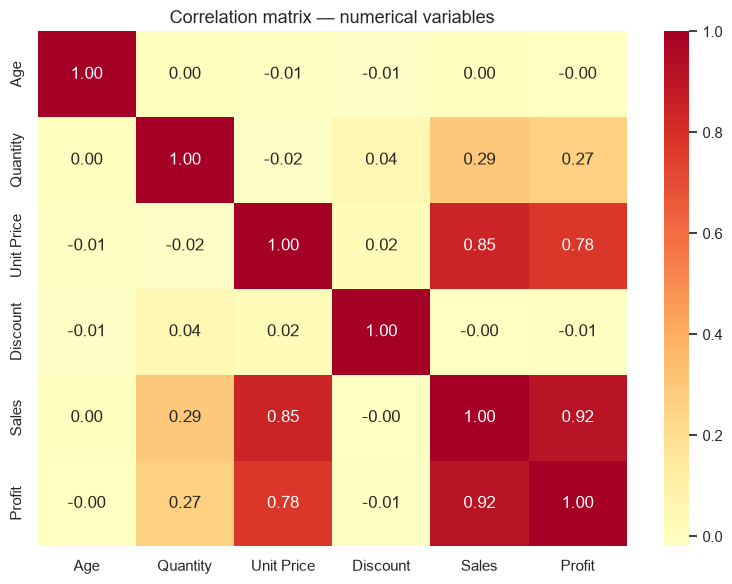

In [7]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0)
plt.title("Correlation matrix — numerical variables")
plt.tight_layout()
plt.show()


**Observation:** Sales and Profit are strongly positively correlated. Quantity and Sales also move together. Discount has a weaker (sometimes slightly negative) link with profit — deeper discounts can grow top-line while squeezing margin.

## 7. Additional insight: weekday × category heatmap (non-obvious)

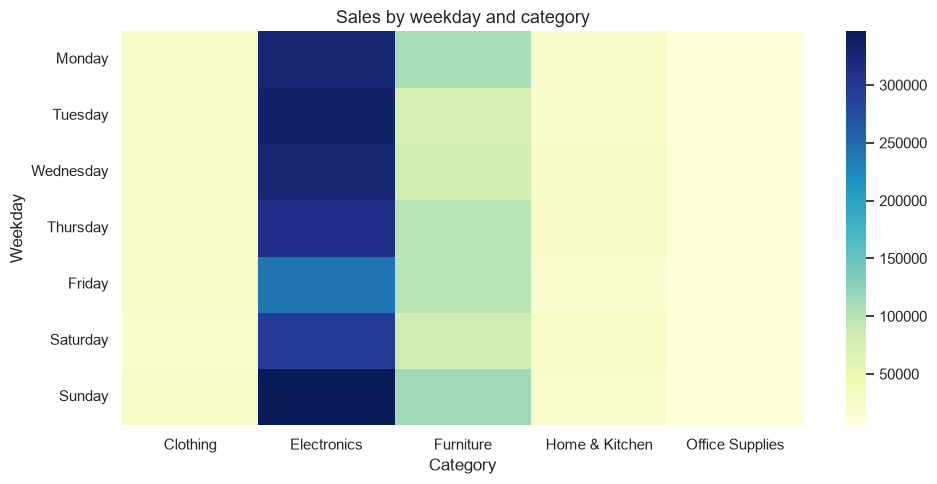

Profit margin by segment × region:


Region,Central,East,South,West
Customer Segment,,,,
Consumer,0.218,0.226,0.211,0.220
Corporate,0.213,0.224,0.207,0.197
Home Office,0.218,0.206,0.230,0.209


In [8]:
extra = df.copy()
extra["Weekday"] = extra["Order Date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = extra.pivot_table(index="Weekday", columns="Category", values="Sales", aggfunc="sum").reindex(order)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=False, cmap="YlGnBu")
plt.title("Sales by weekday and category")
plt.tight_layout()
plt.show()

# Profit rate by segment and region
margin = extra.groupby(["Customer Segment", "Region"]).apply(
    lambda g: g["Profit"].sum() / g["Sales"].sum(), include_groups=False
).unstack()
print("Profit margin by segment × region:")
display(margin.round(3))


**Observation (non-obvious):** Weekend demand is not uniform across categories — some categories spike on Saturday/Sunday while others stay weekday-driven (corporate / office supplies). That is a staffing and promo-timing signal, not just a “sales are higher on weekends” headline.

## 8. Conclusion and actionable recommendations

1. **Protect high-margin electronics/furniture while using office supplies as traffic drivers.** Volume products fill the basket; high-ticket categories pay the bills. Bundle a high-volume item with a mid-ticket accessory.
2. **Time promotions with monthly troughs, not only peak months.** Discounting during already-busy months gives away margin. Use light offers in weak months and inventory-push campaigns before known peaks.
3. **Target the 25–44 core with weekday digital ads and weekend category-specific offers.** Corporate/home-office buyers behave differently from consumers — use segment-specific email cadences rather than one blast.
4. **Watch discount depth.** Because profit tracks sales but discounts can soften margin, cap promotional discount at a level that still keeps contribution positive (validate with the profit–discount scatter in operations).